# Guided Example: Linear Regression for Solar Wind Prediction (ACE EPAM)

This notebook walks through **linear regression** in two ways:

1. **Statistics view**: fit a line and evaluate fit (error).
2. **Machine Learning view**: treat linear regression as a model that is **trained**, **tested**, and used to **predict on unseen data**.

**Dataset (CSV):**  
`ace_epam_2023-02.csv` hosted on S3

---
## Machine Learning Concepts Covered (in markdown as you requested)

- **Inputs (x) / Outputs (y)**  
- **Training vs testing**  
- **Loss function:** Mean Squared Error (MSE)  
- **Generalization** (performance on unseen data)  
- **Overfitting** (conceptual)

> Note: This example uses **time** as the input feature and one EPAM channel as the target.  
> For real forecasting, you'd often use multiple features and/or time-lagged inputs.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

plt.rcParams["figure.figsize"] = (8, 4)


## 1) Load the dataset from S3

We will load the CSV directly from the URL. Then we will:
- inspect columns
- identify a time column (if present)
- select one numeric EPAM channel as the target **y**


In [2]:
DATA_URL = "https://indiajacksonphd.s3.us-east-1.amazonaws.com/NRAO/ace_epam_2023-02.csv"

df = pd.read_csv(DATA_URL)
df.head()


,timestamp,Modified Julian Day,Seconds of the Day,ES,E38-53,E175-315,PS,P47-68,P115-195,P310-580,P795-1193,P1060-1900,Anis. Index
0,2023-02-01T00:00:00,59976,0,0,1200.0,19.3,0,4600.0,19.2,2.26,1.19,0.233,-1.0
1,2023-02-01T00:05:00,59976,300,0,1620.0,18.8,0,4890.0,18.1,2.10,1.18,0.146,-1.0
2,2023-02-01T00:10:00,59976,600,0,1270.0,21.2,0,4960.0,21.7,3.55,1.39,0.108,-1.0
3,2023-02-01T00:15:00,59976,900,0,1200.0,17.8,0,4910.0,22.3,2.76,1.19,0.118,-1.0
4,2023-02-01T00:20:00,59976,1200,0,1490.0,18.0,0,4880.0,19.7,1.99,1.46,0.134,-1.0


In [3]:
df.shape, df.columns.tolist()[:30]  # show first ~30 column names

((8064, 13),
 ['timestamp',
  'Modified Julian Day',
  'Seconds of the Day',
  'ES',
  'E38-53',
  'E175-315',
  'PS',
  'P47-68',
  'P115-195',
  'P310-580',
  'P795-1193',
  'P1060-1900',
  'Anis. Index'])

## 2) Inputs (x) and Outputs (y)

### Inputs (x)
In this example, we use one or more **proton flux channels** as input features.

These channels represent measurements of particle flux at different energy ranges. By using them as inputs, we are testing whether one part of the particle energy spectrum can help predict another.

You can define the input features using:
- `X_COLS` → a list of one or more proton channels

Examples:
- `["P47-68"]` (single input)
- `["P47-68", "P310-580"]` (multiple inputs)

---

### Output (y)
We choose **one proton channel** as the target variable to predict.

This allows us to explore relationships between different energy bands in the dataset.

You can define the target using:
- `Y_COL` → a single proton channel

Example:
- `"P115-195"`

---

### Interpretation

The goal is to determine whether a **linear relationship exists between proton channels**.

If a strong relationship is found, it suggests that different energy bands are physically connected and that one can help predict the behavior of another.

## 3) Visualize the Data

Before modeling, it is important to visualize the relationship between variables.

In this case, we plot one proton channel against another to explore whether a linear relationship exists.

We also highlight **outliers**, which are values that fall far outside the typical range of the data. These points can strongly influence the model and distort the underlying relationship.

By comparing:
- the data **with outliers** (highlighted in red), and  
- the data **without outliers** (removed),

we can better understand the structure of the data and determine whether a linear model is appropriate.

Visualization helps us:
- identify trends between variables  
- detect extreme values (outliers)  
- decide whether preprocessing (such as outlier removal) is needed before modeling

In [4]:
df2 = df.copy()
channels = ["P47-68", "P115-195", "P310-580", "P795-1193", "P1060-1900"]

In [5]:
outlier_masks = {} # store outlier flags

for col in channels: # loop over channels
    Q1 = df2[col].quantile(0.25) # value where 25% of data is below
    Q3 = df2[col].quantile(0.75) # value where 75% of data is below
    IQR = Q3 - Q1 # middle 50% range

    lower = Q1 - 1.5 * IQR # lower cutoff
    upper = Q3 + 1.5 * IQR # upper cutoff

    outlier_masks[col] = (df2[col] < lower) | (df2[col] > upper) # flag extremes

    print(f"{col}: {outlier_masks[col].sum()} outliers")  # count outliers

P47-68: 2368 outliers
P115-195: 2385 outliers
P310-580: 2415 outliers
P795-1193: 1964 outliers
P1060-1900: 2101 outliers


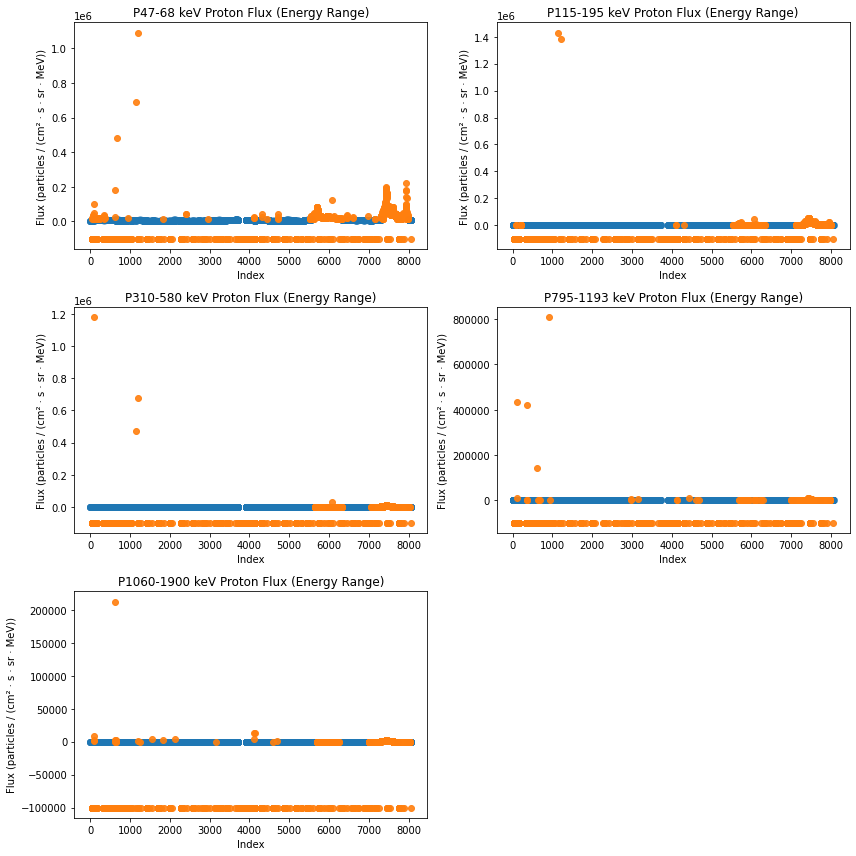

In [19]:
fig = plt.figure(figsize=(12, 12))  # create figure

for i, col in enumerate(channels):  # loop over channels
    ax = plt.subplot(3, 2, i + 1)  # create subplot

    mask = outlier_masks[col]  # get outlier mask

    ax.scatter(df2.index[~mask], df2.loc[~mask, col], alpha=0.4, label="Regular")  # plot regular points
    ax.scatter(df2.index[mask], df2.loc[mask, col], alpha=0.9, label="Outliers")  # plot outliers

    ax.set_title(f"{col} keV Proton Flux (Energy Range)")   # set title
    ax.set_xlabel("Index")  # x-axis label
    ax.set_ylabel("Flux (particles / (cm² · s · sr · MeV))")  # y-axis label

# Hide the 6th empty subplot
ax_empty = plt.subplot(3, 2, 6)  # last subplot
ax_empty.axis("off")  # hide empty plot

plt.tight_layout()  # adjust layout
plt.show()  # display plots

In [7]:
combined_outliers = np.zeros(len(df2), dtype=bool)  # initialize mask

for col in channels:  # loop over channels
    combined_outliers |= outlier_masks[col]  # combine outliers

print("Combined outliers:", combined_outliers.sum())  # count outliers
print("Remaining rows:", (~combined_outliers).sum())  # count remaining

Combined outliers: 2791
Remaining rows: 5273


In [8]:
# ======================================
# Choose input (X) and output (y)
# Students: try different combinations!
# ======================================

# --- Single-channel input ---
X_COLS = ["P47-68"]  # input feature
Y_COL = "P115-195"   # target variable

# Other options:
# X_COLS = ["P115-195"]
# Y_COL = "P47-68"

# X_COLS = ["P47-68"]
# Y_COL = "P310-580"

# X_COLS = ["P47-68"]
# Y_COL = "P795-1193"

# X_COLS = ["P47-68"]
# Y_COL = "P1060-1900"


# --- Multi-channel input (more advanced) ---
# X_COLS = ["P47-68", "P310-580"]  # multiple inputs
# Y_COL = "P115-195"

# X_COLS = ["P47-68", "P115-195", "P310-580"]
# Y_COL = "P795-1193"

# X_COLS = ["P115-195", "P310-580", "P795-1193"]
# Y_COL = "P1060-1900"


# ======================================
# Apply to cleaned data
# ======================================

df_clean = df2.loc[~combined_outliers].copy()  # remove outliers

X_clean = df_clean[X_COLS].astype(float)  # input data
y_clean = df_clean[Y_COL].astype(float)  # target data

print("Using X:", X_COLS)  # show inputs
print("Using y:", Y_COL)   # show target

print("Original shape:", df2.shape)  # original size
print("Cleaned shape:", df_clean.shape)  # cleaned size

Using X: ['P47-68']
Using y: P115-195
Original shape: (8064, 13)
Cleaned shape: (5273, 13)


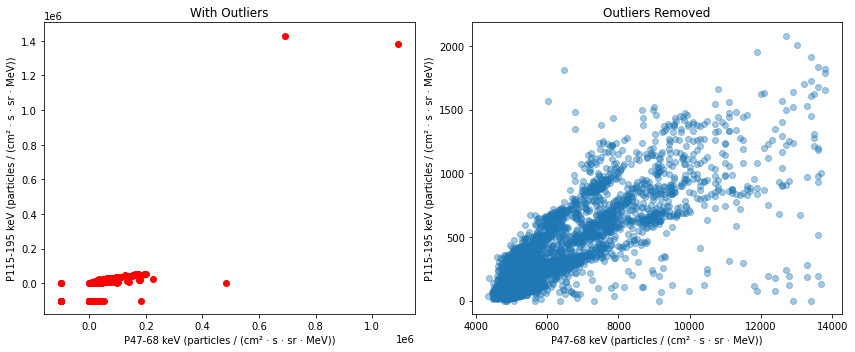

In [17]:
plt.figure(figsize=(12, 5))  # create figure

# --- With outliers ---
plt.subplot(1, 2, 1)  # left plot
plt.scatter(
    df2.loc[~combined_outliers, X_COLS[0]],
    df2.loc[~combined_outliers, Y_COL],
    alpha=0.4
)  # regular points
plt.scatter(
    df2.loc[combined_outliers, X_COLS[0]],
    df2.loc[combined_outliers, Y_COL],
    color='red'
)  # outliers
plt.title("With Outliers")  # title
plt.xlabel(f"{X_COLS[0]} keV (particles / (cm² · s · sr · MeV))")
plt.ylabel(f"{Y_COL} keV (particles / (cm² · s · sr · MeV))")

# --- Without outliers ---
plt.subplot(1, 2, 2)  # right plot
plt.scatter(X_clean.iloc[:, 0], y_clean, alpha=0.4)  # cleaned data
plt.title("Outliers Removed")  # title
plt.xlabel(f"{X_COLS[0]} keV (particles / (cm² · s · sr · MeV))")
plt.ylabel(f"{Y_COL} keV (particles / (cm² · s · sr · MeV))")

plt.tight_layout()  # adjust layout
plt.show()  # display plots

## 4) Training vs Testing

In machine learning, we evaluate performance on **unseen data**.

Here, we split the cleaned dataset into:
- **80% training data**
- **20% testing data**

The training set is used to fit the model, and the testing set is used to evaluate how well the model performs on data it did not see during training.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_clean, 
                                                    y_clean, 
                                                    test_size=0.2, 
                                                    random_state=42) # split data (80/20)

len(X_train), len(X_test) # size of splits

(4218, 1055)

## 5) Train the Model (Fit the Line)

Linear regression learns:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

Where:
- **x** = input proton channel
- **y** = target proton channel

In [11]:
model = LinearRegression()  # create model
model.fit(X_train, y_train)  # train model

print("Intercept (β0):", model.intercept_)  # intercept
print("Slope (β1):", model.coef_[0])  # slope

Intercept (β0): -667.65830142398
Slope (β1): 0.16376243160239212


### Final Linear Regression Model

The fitted linear regression model is:

$$
\hat{y} = -667.66 + 0.164x
$$

where:
- $\hat{y}$ is the predicted proton flux (target channel)
- $x$ is the input proton channel
- $-667.66$ is the intercept ($\beta_0$)
- $0.164$ is the slope ($\beta_1$)

---

### Interpretation

- The **slope (0.164)** indicates that for every 1-unit increase in the input proton channel, the predicted output increases by approximately 0.164 units.
- The **intercept (-667.66)** represents the predicted value when the input is zero, though this may not always have a direct physical meaning in this context.

## 6) Loss Function and Model Evaluation

We quantify prediction error using the **Mean Squared Error (MSE)**:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

We compute MSE for both:
- the **training set** (how well the model fits known data)
- the **testing set** (how well the model generalizes to new data)

---

### Mean Squared Error (MSE)

The Mean Squared Error measures the average squared difference between the predicted and actual values. Because the errors are squared, larger errors are penalized more heavily, making MSE sensitive to large deviations.

However, since the values are squared, MSE is not always easy to interpret directly in terms of the original data.

---

### Root Mean Squared Error (RMSE)

To make interpretation easier, we compute the **Root Mean Squared Error (RMSE)**:

$$
\text{RMSE} = \sqrt{\text{MSE}}
$$

RMSE is expressed in the **same units as the original data**, which makes it more intuitive.

In this context, RMSE represents:

> the approximate average difference between the predicted and actual proton flux values

For example, if RMSE is around 180, this means the model’s predictions are typically off by about 180 units.

---

### Coefficient of Determination ($R^2$)

We also evaluate the model using the **coefficient of determination**, or $R^2$:

$$
R^2 = 1 - \frac{\text{Model Error}}{\text{Total Variability}}
$$

$R^2$ measures how much of the variation in the target variable is explained by the model.

- $R^2 = 1$: perfect fit  
- $R^2 = 0$: model explains none of the variation  
- $0 < R^2 < 1$: partial explanatory power  

In this case, $R^2$ tells us how well one proton channel can explain the variability in another using a linear model.

---

### How These Metrics Are Used in Machine Learning

In machine learning:

- **MSE (and RMSE)** are used to measure prediction error  
- **$R^2$** is used to measure how well the model captures the underlying relationship  

Together, they answer two key questions:

1. **How wrong are the predictions?** → MSE / RMSE  
2. **How useful is the model?** → $R^2$

---

### Interpreting Model Performance

To evaluate whether the model is performing well, we consider:

#### 1. Scale of the Error
RMSE should be compared to the scale of the data. If the error is small relative to the range of values, the model is performing reasonably well.

#### 2. Training vs Testing Performance
- If training and testing errors are **similar**, the model generalizes well  
- If training error is much lower than testing error, the model may be **overfitting**

#### 3. $R^2$ Value
- Higher $R^2$ indicates the model explains more of the variability  
- Moderate $R^2$ suggests a relationship exists, but is not purely linear  

---

### When to Improve the Model

If the model performance is not satisfactory, we can:

- include **additional input features** (e.g., multiple proton channels)
- try **nonlinear models** (e.g., polynomial regression)
- apply **data transformations** (e.g., logarithmic scaling)
- revisit **outlier handling**

---

### When to Stop

We stop improving the model when:

- testing error stops decreasing  
- training and testing errors remain similar  
- the model captures the main trend without overfitting  

---

### Summary

- **MSE** measures prediction error (squared)  
- **RMSE** expresses that error in meaningful units  
- **$R^2$** measures how much of the relationship is explained  

Together, these metrics provide a complete picture of model performance and guide decisions about whether the model is sufficient or needs improvement.

In [12]:
yhat_train = model.predict(X_train)  # predict train
yhat_test  = model.predict(X_test)  # predict test

mse_train = mean_squared_error(y_train, yhat_train)  # train error
mse_test  = mean_squared_error(y_test, yhat_test)  # test error

# Root Mean Squared Error
rmse_train = np.sqrt(mse_train)  # train rmse
rmse_test  = np.sqrt(mse_test)  # test rmse

print("Train MSE:", mse_train)  # print train mse
print("Test  MSE:", mse_test)  # print test mse

print("Train RMSE:", rmse_train)  # print train rmse
print("Test  RMSE:", rmse_test)  # print test rmse

r2_train = r2_score(y_train, yhat_train)  # train r2
r2_test  = r2_score(y_test, yhat_test)  # test r2

print("Train R^2:", r2_train)  # print train r2
print("Test  R^2:", r2_test)  # print test r2

Train MSE: 29357.22935975954
Test  MSE: 38176.716469393425
Train RMSE: 171.33951488130091
Test  RMSE: 195.3886293247215
Train R^2: 0.6945154522597405
Test  R^2: 0.6322615997568178


## 7) Generalization

**Generalization** asks: *Does the model perform well on data it did not see during training?*

- If **test MSE** is similar to **train MSE**, the model generalizes reasonably.
- If **test MSE** is much larger, the model may not generalize (or the relationship is not linear).


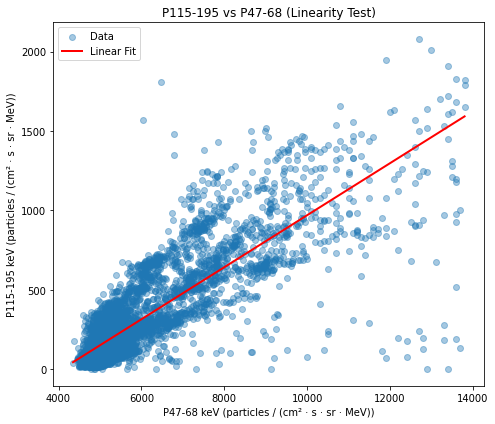

In [15]:
plt.figure(figsize=(7,6))  # create figure

# Scatter (actual data)
plt.scatter(X_clean.iloc[:, 0], y_clean, alpha=0.4, label="Data")  # plot data

# Regression line
x_line = np.linspace(X_clean.iloc[:,0].min(), X_clean.iloc[:,0].max(), 100)  # x range
y_line = model.intercept_ + model.coef_[0] * x_line  # compute line

plt.plot(x_line, y_line, color='red', linewidth=2, label="Linear Fit")  # plot line
plt.xlabel(f"{X_COLS[0]} keV (particles / (cm² · s · sr · MeV))")
plt.ylabel(f"{Y_COL} keV (particles / (cm² · s · sr · MeV))")

plt.title(f"{Y_COL} vs {X_COLS[0]} (Linearity Test)")  # title
plt.legend()  # show legend
plt.tight_layout()  # adjust layout
plt.show()  # display plot

### Baseline Comparison (Sanity Check)

A simple baseline model predicts the **mean of the training data** for every test point.

This provides a reference point to evaluate whether the model is actually learning anything meaningful.

If the model does not outperform the baseline, then it is not useful for this problem.

In this case, the linear regression model achieves a much lower MSE than the baseline, indicating that it captures a meaningful relationship between the proton channels.

In [14]:
baseline_pred = np.full_like(y_test, fill_value=float(y_train.mean()), dtype=float)  # mean prediction
baseline_mse = mean_squared_error(y_test, baseline_pred)  # baseline error

print("Baseline MSE (predict training mean):", baseline_mse)  # print baseline
print("Linear Regression Test MSE:", mse_test)  # print model mse

Baseline MSE (predict training mean): 103876.79283178924
Linear Regression Test MSE: 38176.716469393425


### Overfitting (Conceptual)

Overfitting occurs when a model learns patterns specific to the training data (including noise) and performs poorly on new data.

In this case, linear regression is a simple model, so overfitting is less likely. We check for overfitting by comparing training and testing error — if they are similar, the model generalizes well.

## Wrap-Up

1. Identify **x** and **y** in this example.  
2. Why do we split the data into training and testing sets?  
3. What does MSE measure, and how is it interpreted?  
4. What does it mean for a model to **generalize**?  
5. Describe **overfitting** in your own words (no equations needed).  
6. Why did we remove outliers, and how did this affect the model?  
7. Based on the scatter plot, does the relationship between the proton channels appear fully linear or only partially linear?